In [ ]:
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

## Brief
This Jupyter notebook is a proof of concept of how future crime rate could be forecasted. In this example, SARIMA is used with auto-assigned parameters for simplicity.

Towards the bottom of the notebook, two sets of graphs can be found. The first is how close the forecasted crime rate matches with actual crime count. The second is an example of using the model to predict future crime count for the next six months.

In [4]:
data = pd.read_csv("clean_dataset_week6.csv")

data.head()

,Unnamed: 0,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,0,600dc88bebb3499405cf71237c6a89fa4f0e94f51d669d...,2024-09,Thames Valley Police,Thames Valley Police,-0.704117,51.448857,On or near Winkfield Lane,E01016252,Bracknell Forest 001C,Burglary,Investigation complete; no suspect identified
1,1,96339937ce33810cdd4421d7960675e206d9a57e8cddd7...,2024-09,Thames Valley Police,Thames Valley Police,-0.671521,51.446882,On or near Montague Park,E01016252,Bracknell Forest 001C,Other theft,Unable to prosecute suspect
2,2,48064c2c5c76557638c7d6e9351d59dd3c6a9105a042d5...,2024-09,Thames Valley Police,Thames Valley Police,-0.667887,51.450114,On or near Park Lane,E01016252,Bracknell Forest 001C,Other theft,Status update unavailable
3,3,b88c4f1501e108884efed2d65a1affd624539250adb7c9...,2024-09,Thames Valley Police,Thames Valley Police,-0.672384,51.435490,On or near Lovel Lane,E01016252,Bracknell Forest 001C,Other theft,Investigation complete; no suspect identified
4,4,a8481f9aa2db34e456f19bdbd0620a9e646cb7f98d55a9...,2024-09,Thames Valley Police,Thames Valley Police,-0.677236,51.436336,On or near Lovel Road,E01016252,Bracknell Forest 001C,Violence and sexual offences,Unable to prosecute suspect


In [5]:
crime_trend = data.groupby(['Month', 'Falls within']).size().reset_index(name='count')

crime_trend.head()

,Month,Falls within,count
0,2024-01,Thames Valley Police,15257
1,2024-01,Warwickshire Police,3815
2,2024-01,West Midlands Police,27476
3,2024-01,West Yorkshire Police,23488
4,2024-02,Thames Valley Police,14682


In [21]:
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')

regions = ['Thames Valley Police', 'Warwickshire Police', 'West Midlands Police', 'West Yorkshire Police']

for region in regions:
    region_data = crime_trend[crime_trend['Falls within'] == region].sort_values('Month')
    print(f"ADF test for {region}:")
    check_stationarity(region_data['count'])
    print("\n")

ADF test for Thames Valley Police:
ADF Statistic: -3.7502535142296587
p-value: 0.0034593242297316826
Stationary


ADF test for Warwickshire Police:
ADF Statistic: 0.1835103115678998
p-value: 0.9713214237478858
Non-Stationary


ADF test for West Midlands Police:
ADF Statistic: -1.6505581960959925
p-value: 0.45674932517587324
Non-Stationary


ADF test for West Yorkshire Police:
ADF Statistic: -3.508436726447515
p-value: 0.007773046321284309
Stationary




In [22]:
regions = ['Thames Valley Police', 'Warwickshire Police', 'West Midlands Police', 'West Yorkshire Police']

train_data_per_region = {}
test_data_per_region = {}
sarima_models_per_region = {}

for region in regions:
    region_data = crime_trend[crime_trend['Falls within'] == region].sort_values('Month')
    train_data_per_region[region] = region_data[:-6]
    test_data_per_region[region] = region_data[-6:]
    sarima_models_per_region[region] = auto_arima(train_data_per_region[region]['count'], seasonal=True, m=12)

/Users/lucas/Desktop/jupyter/Rockborne/Rockborne/lib/python3.11/site-packages/pmdarima/arima/utils.py:117: UserWarning: Appropriate D value may not have been reached; length of seasonally-differenced array (7) is shorter than m (12). Using D=1
  warnings.warn("Appropriate D value may not have been reached; "
/Users/lucas/Desktop/jupyter/Rockborne/Rockborne/lib/python3.11/site-packages/pmdarima/arima/utils.py:117: UserWarning: Appropriate D value may not have been reached; length of seasonally-differenced array (7) is shorter than m (12). Using D=1
  warnings.warn("Appropriate D value may not have been reached; "
/Users/lucas/Desktop/jupyter/Rockborne/Rockborne/lib/python3.11/site-packages/pmdarima/arima/utils.py:117: UserWarning: Appropriate D value may not have been reached; length of seasonally-differenced array (7) is shorter than m (12). Using D=1
  warnings.warn("Appropriate D value may not have been reached; "
/Users/lucas/Desktop/jupyter/Rockborne/Rockborne/lib/python3.11/site-p

In [23]:
forecasts_per_region = {}
mse_scores_per_region = {}

for region in regions:
    forecast = sarima_models_per_region[region].predict(n_periods=len(test_data_per_region[region]))
    forecasts_per_region[region] = forecast
    mse_val = mean_squared_error(test_data_per_region[region]['count'], forecast)
    mse_scores_per_region[region] = mse_val
    print(f'Mean Squared Error for {region}: {mse_val}')

Mean Squared Error for Thames Valley Police: 344649.1666666669
Mean Squared Error for Warwickshire Police: 209890.5
Mean Squared Error for West Midlands Police: 351103.28231292573
Mean Squared Error for West Yorkshire Police: 463439.98639455764


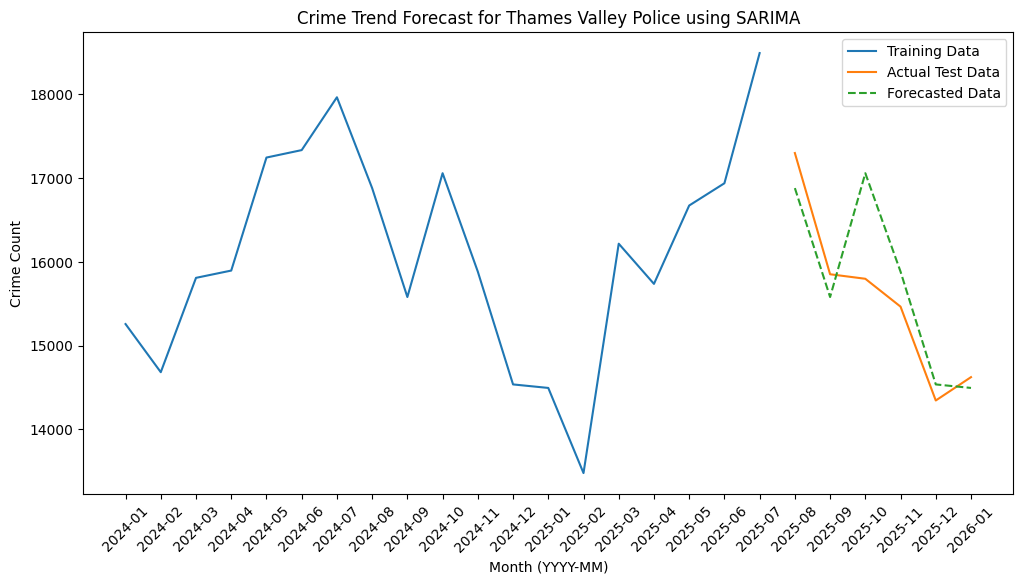

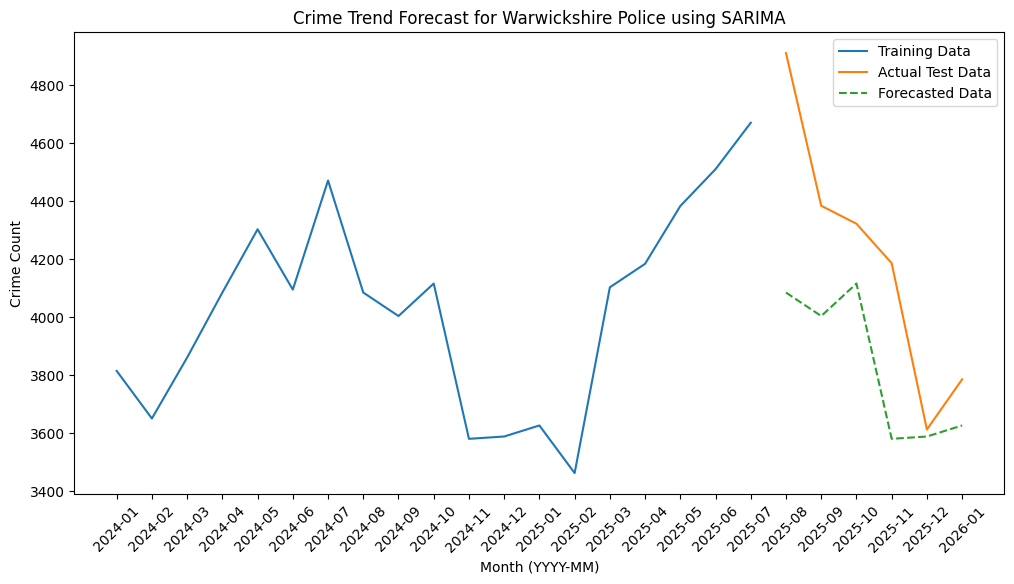

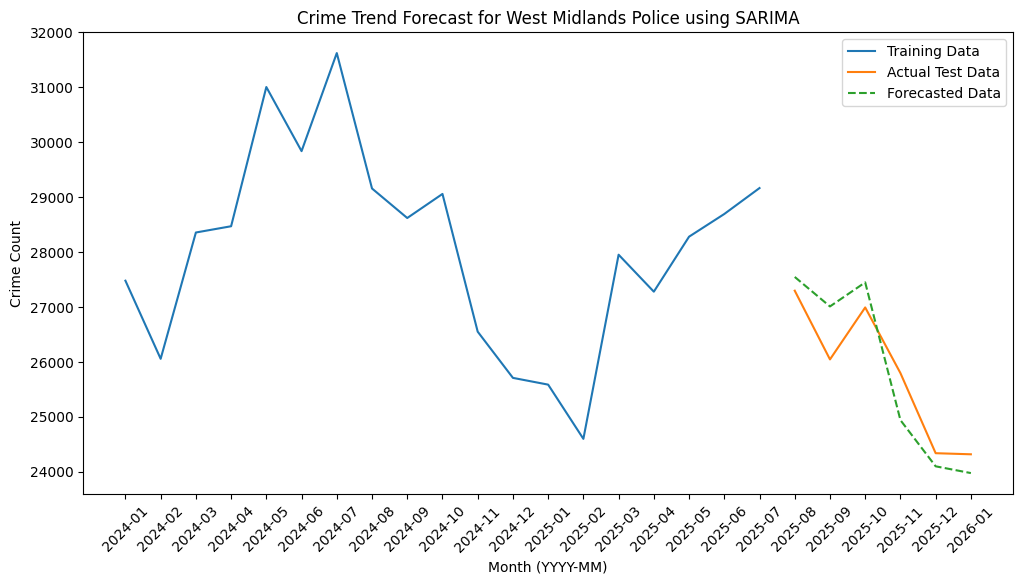

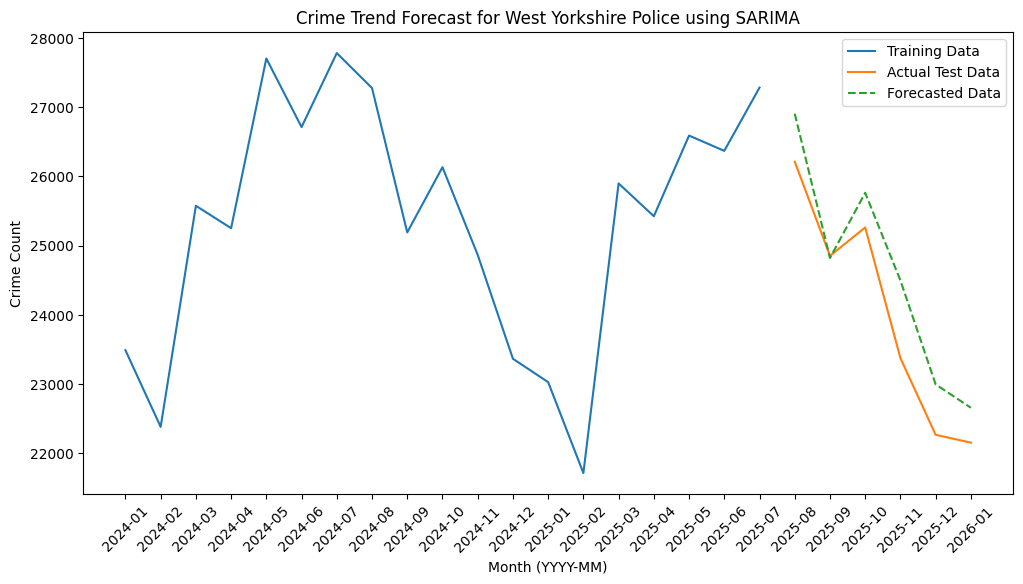

In [ ]:
for region in regions:
    plt.figure(figsize=(12, 6))
    train_data = train_data_per_region[region]
    test_data = test_data_per_region[region]
    forecast = forecasts_per_region[region]
    plt.plot(train_data['Month'], train_data['count'], label='Training Data')
    plt.plot(test_data['Month'], test_data['count'], label='Actual Test Data')
    plt.plot(test_data['Month'], forecast, label='Forecasted Data', linestyle='--')
    plt.xlabel('Mofdfadsfdddggffdddddddddfddddda foaaaaaaaaafdafde')
    plt.ylabel('Crime Count')
    plt.title(f'Crime Trend Forecast for {region} using SARIMA')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

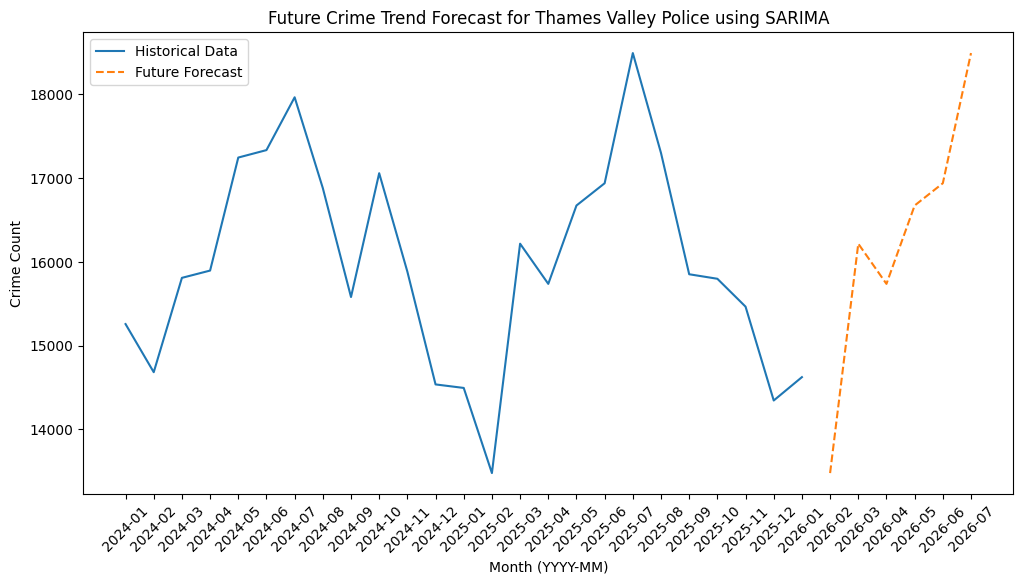

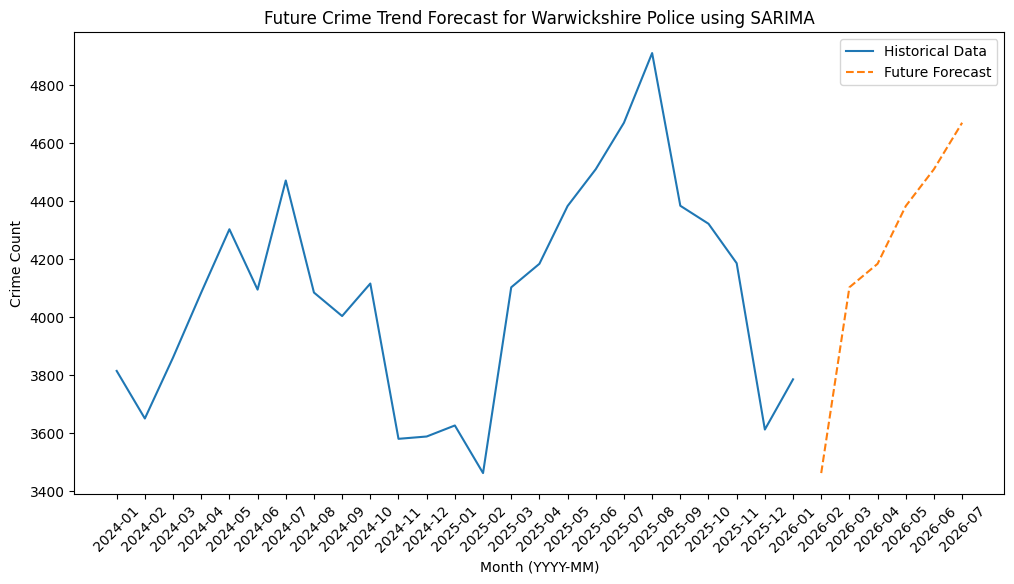

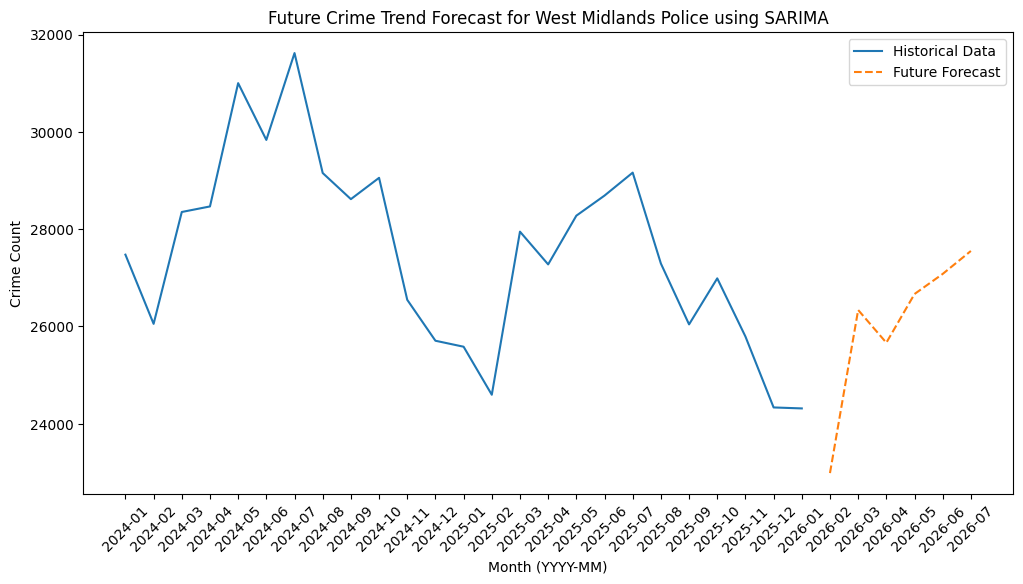

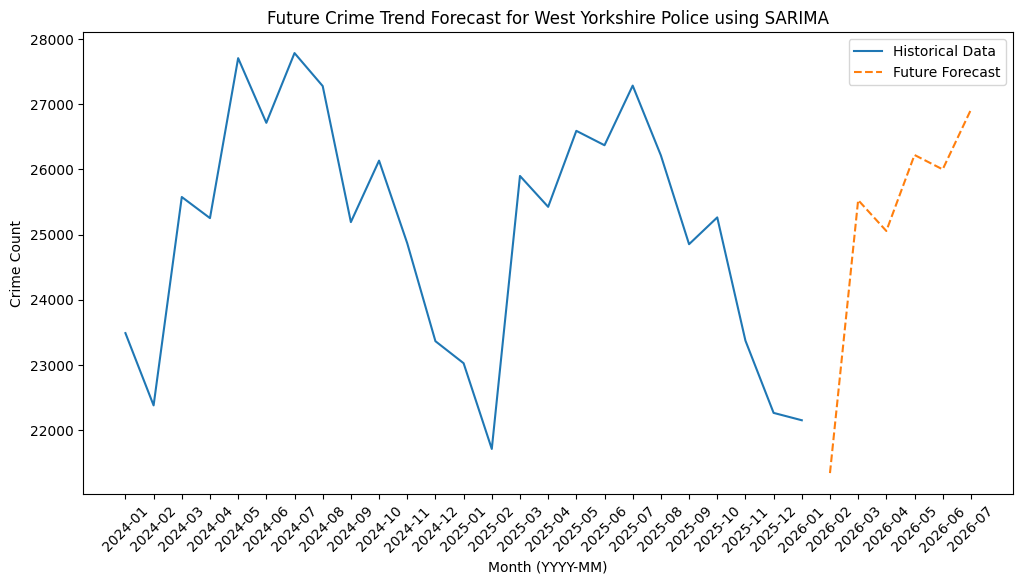

In [ ]:
future_forecasts_per_region = {}
future_periods = 6

for region in regions:
    full_forecast = sarima_models_per_region[region].predict(n_periods=len(test_data_per_region[region]) + future_periods)
    future_forecast = full_forecast[-future_periods:]
    future_forecasts_per_region[region] = future_forecast

for region in regions:
    plt.figure(figsize=(12, 6))
    full_data = pd.concat([train_data_per_region[region], test_data_per_region[region]])
    last_month = pd.to_datetime(test_data_per_region[region]['Month'].iloc[-1])
    future_months = pd.date_range(start=last_month + pd.DateOffset(months=1), periods=future_periods, freq='ME').strftime('%Y-%m').tolist()
    plt.plot(full_data['Month'], full_data['count'], label='Historical Data')
    plt.plot(future_months, future_forecasts_per_region[region], label='Future Forecast', linestyle='--')
    plt.xlabel('Month')
    plt.ylabel('Crime Count')
    plt.title(f'Future Crime Trend Forecast for {region} using SARIMA')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()